<a href="https://colab.research.google.com/github/DilakshanRahul12/CM2604/blob/RF/RF_bank_additional_all.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [10]:
from google.colab import drive
drive.mount('/content/drive')
dataset = '/content/drive/MyDrive/CM2604/dataset/bank-additional/bank-additional-full.csv'
df = pd.read_csv(dataset, sep=';')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


Outlier handling

In [11]:
df_dur = df[df['duration'] < 814].copy()
df_dur.shape

(39504, 21)

In [12]:
df_dur['age'] = df_dur['age'].apply(lambda x: 66 if x > 66 else x)

In [13]:
df_dur['campaign'] = np.log1p(df_dur['campaign'])

In [14]:
# Define a function to categorize 'pdays'
def categorize_pdays(pdays):
    if 0 <= pdays <= 30:
        return 'recently contacted'
    elif 31 <= pdays <= 90:
        return 'contacted few months ago'
    elif 91 <= pdays <= 998:
        return 'contacted long ago'
    elif pdays == 999:
        return 'not contacted'

# Apply the function to create the new categorical feature
df_dur['pdays'] = df_dur['pdays'].apply(categorize_pdays)

In [15]:
df_dur['previous'] = np.log1p(df_dur['previous'])

In [16]:
df_handled = df_dur.copy()
df_handled.shape

(39504, 21)

In [17]:
df_handled['duration'] = np.log1p(df_handled['duration'])  # log(1 + x) for duration

In [18]:
df_encoded1 = df_handled.copy()

In [19]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoders and store mappings
label_encoders = {}
mappings = {}

# Iterate through categorical columns
for column in df_encoded1.select_dtypes(include=['object']):
    le = LabelEncoder()
    df_encoded1[column] = le.fit_transform(df_encoded1[column])
    label_encoders[column] = le
    mappings[column] = dict(zip(le.classes_, le.transform(le.classes_)))

# Display the mappings

for column, mapping in mappings.items():
    print(f"Mappings for column '{column}':")
    print(mapping)
    print("---")


Mappings for column 'job':
{'admin.': 0, 'blue-collar': 1, 'entrepreneur': 2, 'housemaid': 3, 'management': 4, 'retired': 5, 'self-employed': 6, 'services': 7, 'student': 8, 'technician': 9, 'unemployed': 10, 'unknown': 11}
---
Mappings for column 'marital':
{'divorced': 0, 'married': 1, 'single': 2, 'unknown': 3}
---
Mappings for column 'education':
{'basic.4y': 0, 'basic.6y': 1, 'basic.9y': 2, 'high.school': 3, 'illiterate': 4, 'professional.course': 5, 'university.degree': 6, 'unknown': 7}
---
Mappings for column 'default':
{'no': 0, 'unknown': 1, 'yes': 2}
---
Mappings for column 'housing':
{'no': 0, 'unknown': 1, 'yes': 2}
---
Mappings for column 'loan':
{'no': 0, 'unknown': 1, 'yes': 2}
---
Mappings for column 'contact':
{'cellular': 0, 'telephone': 1}
---
Mappings for column 'month':
{'apr': 0, 'aug': 1, 'dec': 2, 'jul': 3, 'jun': 4, 'mar': 5, 'may': 6, 'nov': 7, 'oct': 8, 'sep': 9}
---
Mappings for column 'day_of_week':
{'fri': 0, 'mon': 1, 'thu': 2, 'tue': 3, 'wed': 4}
---
Map

In [20]:
df_feat = df_encoded1.copy()

In [21]:
# from sklearn.decomposition import PCA

# pca = PCA(n_components=1)
# economic_features1 = df_feat[['emp.var.rate', 'cons.price.idx', 'cons.conf.idx']]
# df_feat['economic1'] = pca.fit_transform(economic_features1)
# print(f"Explained Variance Ratio: {pca.explained_variance_ratio_}")

In [22]:
# economic_features2 = df_feat[['euribor3m', 'nr.employed']]
# df_feat['economic2'] = pca.fit_transform(economic_features2)
# print(f"Explained Variance Ratio: {pca.explained_variance_ratio_}")

In [23]:
# economic_features3 = df_feat[['emp.var.rate', 'cons.price.idx', 'euribor3m', 'nr.employed']]
# df_feat['economic3'] = pca.fit_transform(economic_features2)
# print(f"Explained Variance Ratio: {pca.explained_variance_ratio_}")

In [24]:
df_dt = df_feat.copy()
# df_dt.drop('emp.var.rate',axis = 1,inplace = True)
# df_dt.drop('cons.price.idx',axis = 1,inplace = True)
# df_dt.drop('cons.conf.idx',axis = 1,inplace = True)
# df_dt.drop('euribor3m',axis = 1,inplace = True)
# df_dt.drop('nr.employed',axis = 1,inplace = True)

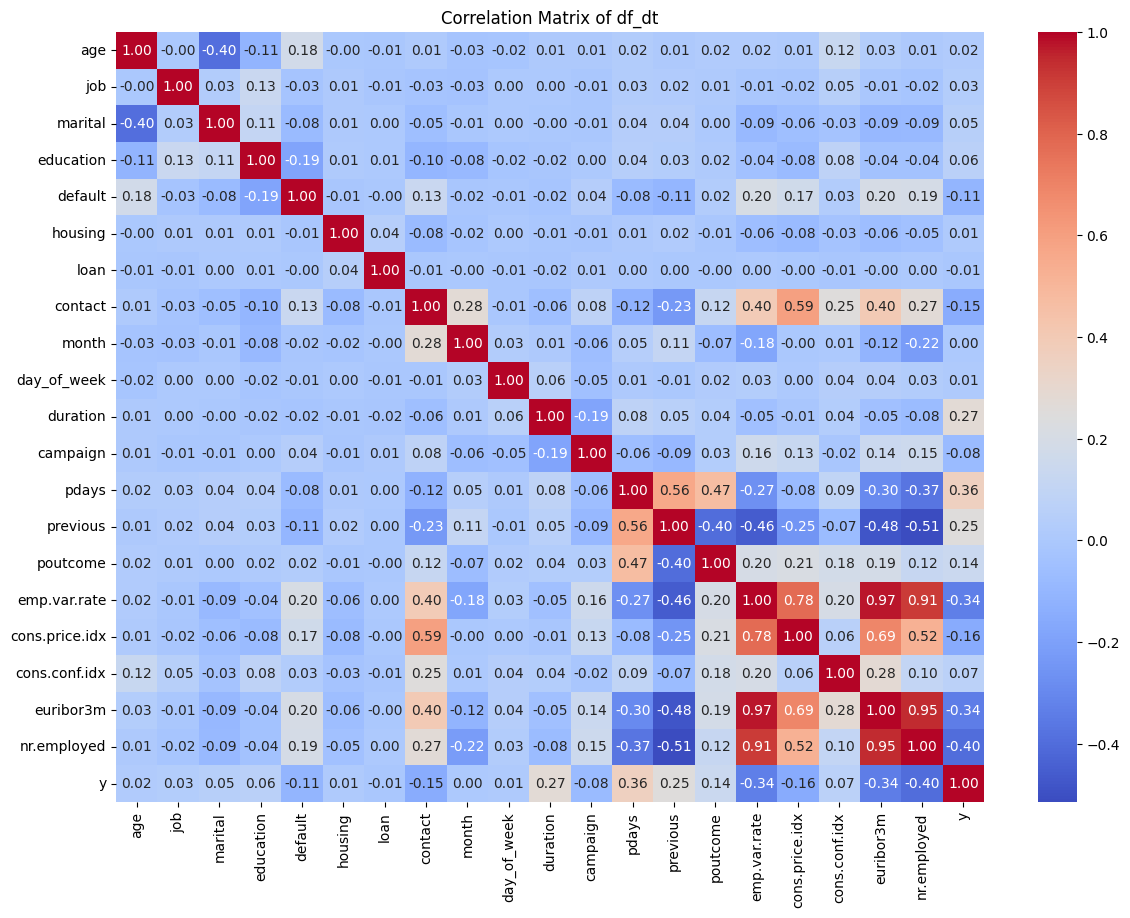

In [25]:
correlation_matrix = df_dt.corr()

# Plot a heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix of df_dt")
plt.show()

Model Normal

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Assuming df_dt is your preprocessed DataFrame and 'y' is your target variable column
X = df_dt.drop('y', axis=1)
y = df_dt['y']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=11)

# Initialize and train a RandomForestClassifier
#rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42) # You can adjust hyperparameters
rf_classifier = RandomForestClassifier()
rf_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_classifier.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy}")
print(classification_report(y_test, y_pred))

Test Accuracy: 0.9306446169422882
              precision    recall  f1-score   support

           0       0.95      0.97      0.96     10773
           1       0.66      0.49      0.56      1079

    accuracy                           0.93     11852
   macro avg       0.81      0.73      0.76     11852
weighted avg       0.92      0.93      0.93     11852



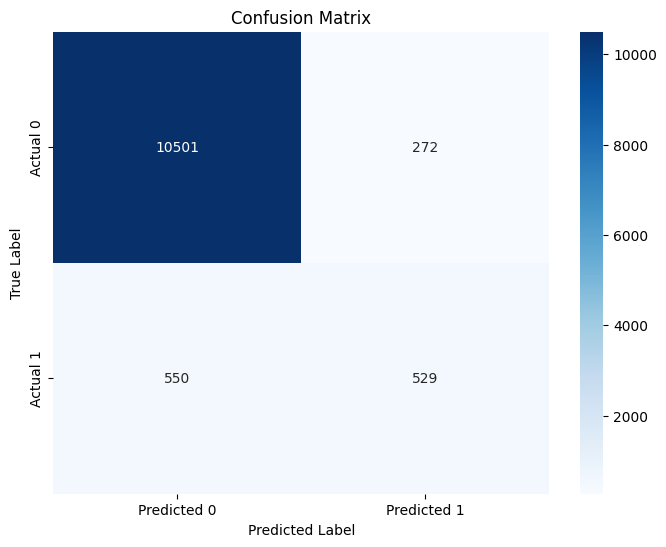

In [34]:
from sklearn.metrics import confusion_matrix

# Assuming y_test and y_pred are defined from your previous code

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

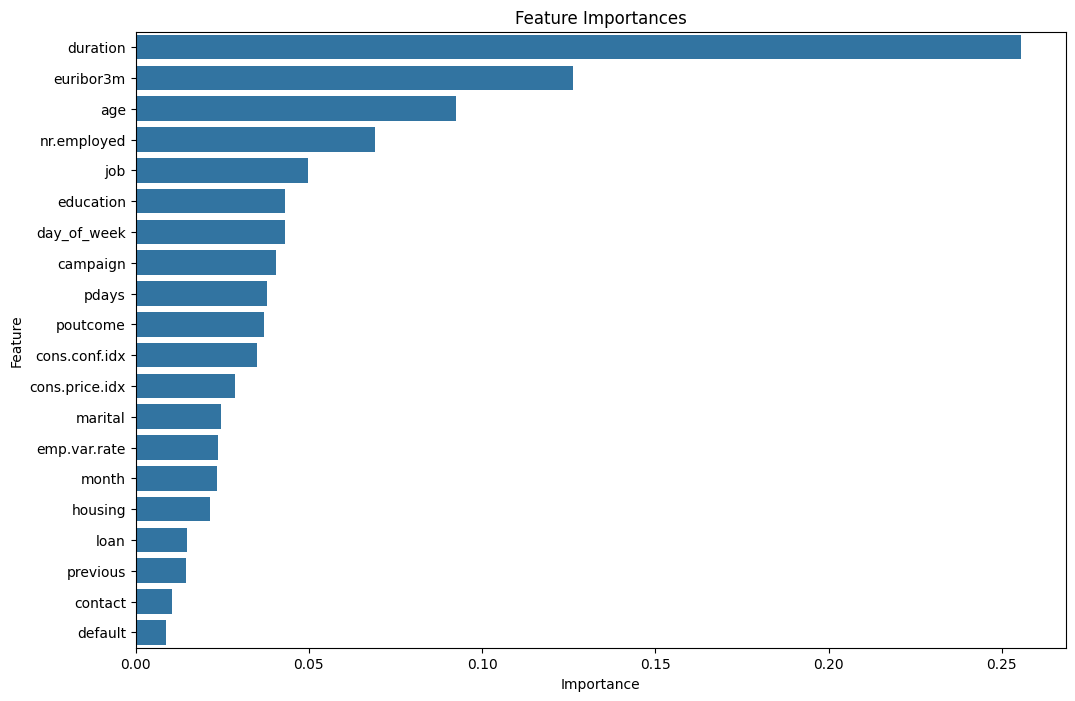

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
importances = rf_classifier.feature_importances_
feature_names = X_train.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Create a bar plot
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

#### hyperparmeter

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for the RandomForestClassifier
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Initialize the GridSearchCV object
grid_search = GridSearchCV(estimator=rf_classifier, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=4, verbose=3)

# Fit the grid search to the training data
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(), n_jobs=4,
             param_grid={'max_depth': [10, 20], 'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [50, 100]},
             scoring='accuracy', verbose=3)

In [ ]:
# Print the best hyperparameters and the corresponding accuracy score
print("Best hyperparameters:", grid_search.best_params_)
print("Best accuracy score:", grid_search.best_score_)

# Evaluate the best model on the test set
best_rf_classifier = grid_search.best_estimator_
y_pred = best_rf_classifier.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of best model on test set: {accuracy}")
print(classification_report(y_test, y_pred))

Best hyperparameters: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Best accuracy score: 0.9314333774814518
Accuracy of best model on test set: 0.8523892570631322
              precision    recall  f1-score   support

           0       0.78      0.99      0.87      7224
           1       0.99      0.71      0.83      7111

    accuracy                           0.85     14335
   macro avg       0.88      0.85      0.85     14335
weighted avg       0.88      0.85      0.85     14335



HP2

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for the RandomForestClassifier
param_grid = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 7],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize the GridSearchCV object
grid_search = GridSearchCV(estimator=rf_classifier, param_grid=param_grid, cv=3, scoring='accuracy', n_jobs=4, verbose=3)

# Fit the grid search to the training data
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 108 candidates, totalling 324 fits


GridSearchCV(cv=3, estimator=RandomForestClassifier(), n_jobs=4,
             param_grid={'max_depth': [10, 20, 30],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 7],
                         'n_estimators': [50, 100, 150, 200]},
             scoring='accuracy', verbose=3)

In [ ]:
# Print the best hyperparameters and the corresponding accuracy score
print("Best hyperparameters:", grid_search.best_params_)
print("Best accuracy score:", grid_search.best_score_)

# Evaluate the best model on the test set
best_rf_classifier = grid_search.best_estimator_
y_pred = best_rf_classifier.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of best model on test set: {accuracy}")
print(classification_report(y_test, y_pred))

Best hyperparameters: {'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Best accuracy score: 0.966443994300572
Accuracy of best model on test set: 0.9776770143006627
              precision    recall  f1-score   support

           0       1.00      0.96      0.98      7224
           1       0.96      1.00      0.98      7111

    accuracy                           0.98     14335
   macro avg       0.98      0.98      0.98     14335
weighted avg       0.98      0.98      0.98     14335



#### ?Bagging

In [37]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split

X = df_dt.drop('y', axis=1)
y = df_dt['y']

# Address class imbalance using RandomOverSampler
oversampler = RandomOverSampler(random_state=42)
X_resampled, y_resampled = oversampler.fit_resample(X, y)

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

from sklearn.ensemble import RandomForestClassifier

# Initialize and train a RandomForestClassifier
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42)  # Adjust n_estimators as needed
random_forest_model.fit(X_train, y_train)

# Make predictions and evaluate the model
y_pred_rf = random_forest_model.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy of Random Forest Classifier: {accuracy_rf}")

print(classification_report(y_test, y_pred_rf))

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


Accuracy of Random Forest Classifier: 0.9779560516219045
              precision    recall  f1-score   support

           0       1.00      0.96      0.98      7224
           1       0.96      1.00      0.98      7111

    accuracy                           0.98     14335
   macro avg       0.98      0.98      0.98     14335
weighted avg       0.98      0.98      0.98     14335



proper oversample

In [52]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=11)

oversampler = RandomOverSampler(random_state=11,sampling_strategy='minority')
X_resampled, y_resampled = oversampler.fit_resample(X_train, y_train)

from sklearn.ensemble import RandomForestClassifier

# Initialize and train a RandomForestClassifier
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42)  # Adjust n_estimators as needed
random_forest_model.fit(X_resampled, y_resampled)

# Make predictions and evaluate the model
y_pred_rf = random_forest_model.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy of Random Forest Classifier: {accuracy_rf}")

print(classification_report(y_test, y_pred_rf))

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


Accuracy of Random Forest Classifier: 0.9265915706872547
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      7178
           1       0.60      0.59      0.59       723

    accuracy                           0.93      7901
   macro avg       0.78      0.77      0.78      7901
weighted avg       0.93      0.93      0.93      7901



### oversampled whole dataset

In [51]:
# Address class imbalance using RandomUnderSampler
from imblearn.under_sampling import RandomUnderSampler

X = df_dt.drop('y', axis=1)
y = df_dt['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=11)

X_resampled, y_resampled = RandomUnderSampler(random_state=11,sampling_strategy='not minority').fit_resample(X_train, y_train)

# Initialize and train a RandomForestClassifier (or your preferred model)
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=11)
random_forest_model.fit(X_resampled, y_resampled)

# Make predictions and evaluate the model
y_pred_rf = random_forest_model.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy of Random Forest Classifier (Undersampled): {accuracy_rf}")

print(classification_report(y_test, y_pred_rf))

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


Accuracy of Random Forest Classifier (Undersampled): 0.8593848879888621
              precision    recall  f1-score   support

           0       0.99      0.85      0.92      7178
           1       0.39      0.93      0.55       723

    accuracy                           0.86      7901
   macro avg       0.69      0.89      0.73      7901
weighted avg       0.94      0.86      0.88      7901



In [50]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Assuming df_dt is your preprocessed DataFrame and 'y' is your target variable column
X = df_dt.drop('y', axis=1)
y = df_dt['y']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=11)

from imblearn.over_sampling import SMOTE
# Apply SMOTE to the training data
smote = SMOTE(sampling_strategy='minority')
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Initialize and train a RandomForestClassifier (or your preferred model)
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=11)
random_forest_model.fit(X_resampled, y_resampled)

# Make predictions and evaluate the model
y_pred_rf = random_forest_model.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy of Random Forest Classifier (Undersampled): {accuracy_rf}")

print(classification_report(y_test, y_pred_rf))

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


Accuracy of Random Forest Classifier (Undersampled): 0.8593848879888621
              precision    recall  f1-score   support

           0       0.99      0.85      0.92      7178
           1       0.39      0.93      0.55       723

    accuracy                           0.86      7901
   macro avg       0.69      0.89      0.73      7901
weighted avg       0.94      0.86      0.88      7901

